In [1]:
import seaborn as sb
import pingouin as pg
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams

plt.style.use('paper_style.mplstyle')

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Load Data

In [2]:
df = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_total_weighted_5std_all.csv')
info = pd.read_csv('/Volumes/AM_SSD1/Spont2P/Data_info.csv')
#df = df.drop(['Unnamed: 0'],axis=1)
df_reg = df.loc[(df['Baseline']!=-1)&(df['Post']!=-1)]

animals = np.unique(df['Animal'])
len(animals)

16

In [3]:
def calculate_deciles_ani(ani_df):
    animal = ani_df['Animal'].values[0]
    ani_df['Decile']=pd.qcut(ani_df['Event Rate'], 10,labels=False)
    # ani_df['Decile']=ani_df['Decile']+1
    decile_ptagged = [ani_df.loc[(ani_df['Decile']==d)&(ani_df['Population']=='Tagged')].shape[0] 
                  / ani_df.loc[(ani_df['Decile']==d)].shape[0] for d in np.unique(ani_df['Decile'])]
    decile_means = [ani_df['Event Rate'].loc[ani_df['Decile']==d].mean() for d in np.unique(ani_df['Decile'])]
    df = pd.DataFrame()
    df['Animal']=[animal]*10
    df['Decile Mean Rates']=decile_means
    df['P(Tagged)']=decile_ptagged
    return df,ani_df

# All mice

In [4]:
deciles = pd.DataFrame()
for ani in animals:
    ani_df = df.loc[(df['Animal']==ani)&(df['Session']=='Baseline')].reset_index(drop=True)
    group = info['Group'].loc[info['Animal']==ani].values[0]
    df_ani,cells_df= calculate_deciles_ani(ani_df)
    df_ani['Deciles'] = np.arange(1,11)
    df_ani['Group'] = [group]*10
    deciles = pd.concat([deciles,df_ani],ignore_index=True)

deciles['Decile']=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']*len(animals)

In [5]:
deciles.to_csv('deciles_spont.csv')

In [6]:
Y = [np.mean(deciles['P(Tagged)'].loc[deciles['Deciles']==d].values) for d in np.arange(1,11)]
X = np.arange(0,10)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()

pred_ols = results.get_prediction()
ci_low = pred_ols.summary_frame()["mean_ci_lower"]
ci_hi = pred_ols.summary_frame()["mean_ci_upper"]
results.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     35.66
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000334
Time:                        15:05:52   Log-Likelihood:                 22.037
No. Observations:                  10   AIC:                            -40.07
Df Residuals:                       8   BIC:                            -39.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2406      0.018     13.706      0.000       0.200       0.281
x1             0.0196      0.003      5.972      0.000       0.012       0.027
==============================================================================
Omnibus:                        0.497   Durbin-Watson:                   2.419
Prob(Omnibus):                  0.780   Jarque-Bera (JB):                0.493
Skew:                          -0.001   Prob(JB):                        0.781
Kurtosis:                       1.912   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
pval=results.f_pvalue
rsq=results.rsquared

In [8]:
cmap = mpl.cm.get_cmap('coolwarm')
colors = np.linspace(0,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
deciles['color'] = [cmap(colors[i]) for i in range(len(colors))]*len(animals)

<ErrorbarContainer object of 3 artists>

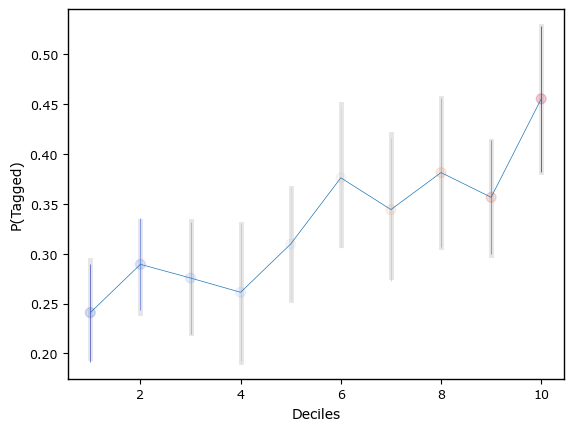

In [9]:
sb.regplot(data=deciles,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=95,fit_reg=False,color='gray',scatter_kws={'alpha':.2,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
ax1 = plt.gca()
lower = [line.get_ydata().min() for line in ax1.lines]
upper = [line.get_ydata().max() for line in ax1.lines]
means = ax1.collections[0].get_offsets()[:, 1]
errs = (np.array(upper)-np.array(lower))/2
plt.errorbar(np.arange(1,11),means,yerr=errs,linewidth=.5,ecolor=tencolors)

<AxesSubplot: xlabel='Deciles', ylabel='P(Tagged)'>

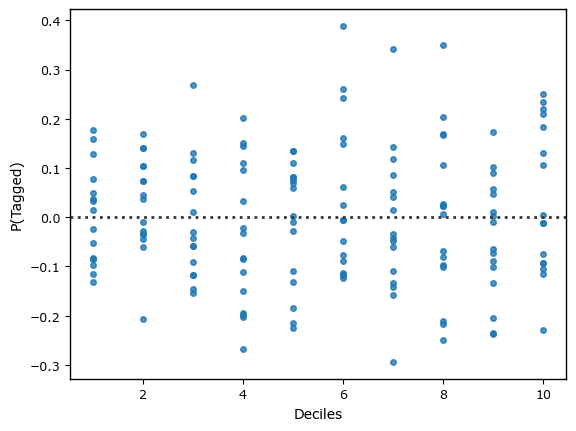

In [10]:
sb.residplot(data=deciles,x='Deciles',y='P(Tagged)')

## Figure 2D

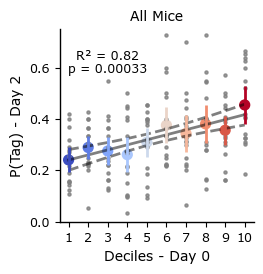

In [11]:
cmap = mpl.cm.get_cmap('coolwarm')
colors = np.linspace(0,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
fig,ax=plt.subplots(figsize=(2.5,2.5))

#regression
plt.plot(np.arange(1,11),results.fittedvalues,'k',alpha=.5)
plt.plot(np.arange(1,11),ci_low,'k--',alpha=.5)
plt.plot(np.arange(1,11),ci_hi,'k--',alpha=.5)
#data
sb.regplot(data=deciles,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
plt.errorbar(np.arange(1,11),means,yerr=errs,linewidth=2,ecolor=tencolors,linestyle='')
sb.regplot(data=deciles,x='Deciles',y='P(Tagged)',fit_reg=False,color='grey',scatter_kws={'s':5})
#labels axes
plt.ylabel('P(Tag) - Day 2')
plt.xlabel('Deciles - Day 0')
plt.xticks(np.arange(1,11))
plt.ylim([0,.75])
#statistics
plt.text(3,.63,f"R\u00b2 = {np.round(rsq,2)}",ha='center',size=9)
plt.text(3,.58,f"p = {np.round(pval,5):.5f}",ha='center',size=9)
plt.title('All Mice',size=10)
sb.despine()
plt.savefig('Fig3D_deciles_baselinerate_ptag_all.svg',transparent=True)

#### individual mice trends

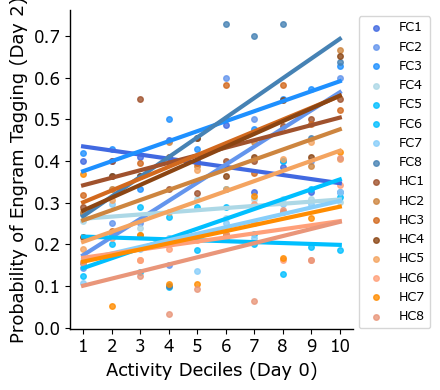

In [12]:
deciles['Mouse']=deciles['Animal'].map({'9972R':'FC1','992N':'FC2','989N':'FC3',
           '149L':'FC4','146R':'FC5','160R':'FC6','492N':'FC7','493R':'FC8',
           '589L':'HC1','992L':'HC2','994R':'HC3',
           '034R':'HC4','217N':'HC5','218L':'HC6','217R':'HC7','1912L':'HC8'})
palette = {'FC1':'royalblue','FC2':'cornflowerblue','FC3':'dodgerblue','FC4':'#ADD8E6','FC5':'#00BFFF','FC6':'deepskyblue','FC7':'lightskyblue','FC8':'steelblue',	
        'HC1':'sienna','HC2':'peru','HC3':'chocolate','HC4':'saddlebrown','HC5':'sandybrown','HC6':'lightsalmon','HC7':'darkorange','HC8':'darksalmon'}
hue_order=['FC1','FC2','FC3','FC4','FC5','FC6','FC7','FC8','HC1','HC2','HC3','HC4','HC5','HC6','HC7','HC8']

g=sb.lmplot(data=deciles,x='Deciles',y='P(Tagged)',hue='Mouse',ci=None, hue_order=hue_order,
            legend=False,palette=palette,height=4,aspect=4.5/4)
plt.xlabel('Activity Deciles (Day 0)',size=13)
plt.ylabel('Probability of Engram Tagging (Day 2)',size=13)
plt.yticks(size=12)
plt.xticks(np.arange(1,11),labels=np.arange(1,11),size=12)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()


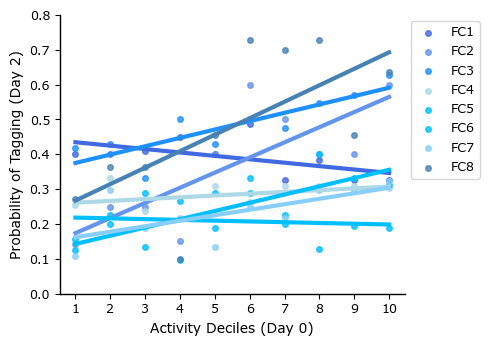

In [13]:


sb.set_palette('pastel')
g=sb.lmplot(data=deciles.loc[deciles['Group']=='FC'],x='Deciles',y='P(Tagged)',hue='Mouse',ci=None,
            hue_order=hue_order,
            legend=False,palette=palette)
g.axes[0][0].set_xticks(ticks=np.arange(1,11))
g.axes[0][0].set_xticklabels(labels=np.arange(1,11))
g.axes[0][0].set_aspect(10)
plt.xlabel('Activity Deciles (Day 0)',size=10)
plt.ylabel('Probability of Tagging (Day 2)',size=10)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.ylim([0,.8])
plt.tight_layout()


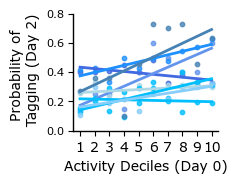

In [14]:
sb.set_palette('pastel')
g=sb.lmplot(data=deciles.loc[deciles['Group']=='FC'],x='Deciles',y='P(Tagged)',hue='Mouse',ci=None,height=3,aspect=.8,
            hue_order=['FC1','FC2','FC3','FC4','FC5','FC6','FC7','FC8'],
            legend=False,palette=palette,
            scatter_kws={'s':10},line_kws={'linewidth':2})
g.axes[0][0].set_xticks(ticks=np.arange(1,11))
g.axes[0][0].set_xticklabels(labels=np.arange(1,11))
g.axes[0][0].set_aspect(10)
plt.xlabel('Activity Deciles (Day 0)',size=10)
plt.ylabel('Probability of \n Tagging (Day 2)',size=10)
plt.ylim([0,.8])
plt.xticks(np.arange(1,11),size=10)
plt.yticks(size=8)
plt.tight_layout()
plt.savefig('dbaseline_deciles_FC_mice_lines.svg',transparent=True)

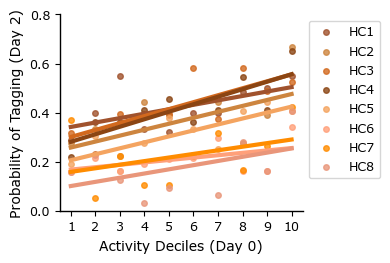

In [15]:
##Figure S2.
sb.set_palette('pastel')
g=sb.lmplot(data=deciles.loc[deciles['Group']=='HC'],x='Deciles',y='P(Tagged)',hue='Mouse',ci=None,height=4,aspect=1,
            hue_order=['HC1','HC2','HC3','HC4','HC5','HC6','HC7','HC8'], legend=False,
            palette=palette)
g.axes[0][0].set_xticks(ticks=np.arange(1,11))
g.axes[0][0].set_xticklabels(labels=np.arange(1,11))
g.axes[0][0].set_aspect(10)
plt.xlabel('Activity Deciles (Day 0)',size=10)
plt.ylabel('Probability of Tagging (Day 2)',size=10)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.ylim([0,.8])
plt.tight_layout()


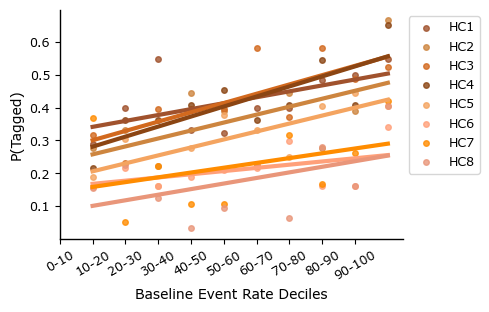

In [16]:
sb.set_palette('pastel')

g=sb.lmplot(data=deciles.loc[deciles['Group']=='HC'],x='Deciles',y='P(Tagged)',hue='Mouse',ci=None,
            hue_order=['HC1','HC2','HC3','HC4','HC5','HC6','HC7','HC8'],
            legend=False,palette=palette)
g.axes[0][0].set_xticks(ticks=np.arange(0,10))
g.axes[0][0].set_xticklabels(labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100'],rotation=30)
g.axes[0][0].set_aspect(10)
plt.xlabel('Baseline Event Rate Deciles')
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()


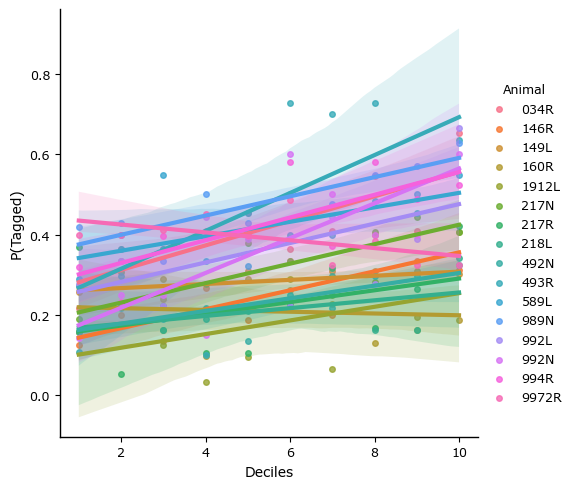

In [17]:
sb.set_palette('pastel')
sb.lmplot(data=deciles,x='Deciles',y='P(Tagged)',hue='Animal')

# FC MICE ONLY

In [18]:
### plot only fc mice
deciles_fc = pd.DataFrame()
fc_mice = ['992N','989N','146R','149L','9972R','160R','492N','493R']
for ani in fc_mice:
    ani_df = df.loc[(df['Animal']==ani)&(df['Session']=='Baseline')].reset_index(drop=True)
    df_ani,cells_df= calculate_deciles_ani(ani_df)
    df_ani['Deciles'] = np.arange(1,11)
    deciles_fc = pd.concat([deciles_fc,df_ani],ignore_index=True)

deciles_fc['Decile']=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']*len(fc_mice)

## Figure 2E Stats

In [19]:
Y = [np.mean(deciles_fc['P(Tagged)'].loc[deciles_fc['Deciles']==d].values) for d in np.arange(1,11)]
X = np.arange(0,10)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()

pred_ols = results.get_prediction()
ci_low = pred_ols.summary_frame()["mean_ci_lower"]
ci_hi = pred_ols.summary_frame()["mean_ci_upper"]
pval = results.f_pvalue
rsq = results.rsquared

results.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     14.88
Date:                Mon, 04 May 2026   Prob (F-statistic):            0.00482
Time:                        15:05:56   Log-Likelihood:                 18.317
No. Observations:                  10   AIC:                            -32.63
Df Residuals:                       8   BIC:                            -32.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2545      0.025      9.995      0.000       0.196       0.313
x1             0.0184      0.005      3.858      0.005       0.007       0.029
==============================================================================
Omnibus:                        2.276   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.320   Jarque-Bera (JB):                0.689
Skew:                           0.640   Prob(JB):                        0.708
Kurtosis:                       3.127   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<ErrorbarContainer object of 3 artists>

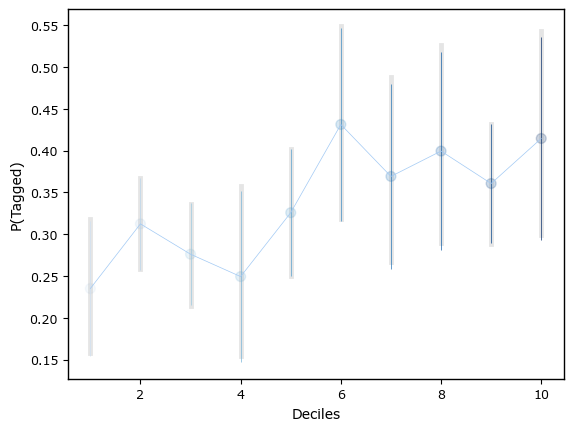

In [20]:
cmap=mpl.cm.get_cmap('Blues')
colors = np.linspace(.2,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
deciles_fc['color'] = [cmap(colors[i]) for i in range(len(colors))]*len(fc_mice)
sb.regplot(data=deciles_fc,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=95,fit_reg=False,color='gray',scatter_kws={'alpha':.2,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
ax1 = plt.gca()
lower = [line.get_ydata().min() for line in ax1.lines]
upper = [line.get_ydata().max() for line in ax1.lines]
means = ax1.collections[0].get_offsets()[:, 1]
errs = (np.array(upper)-np.array(lower))/2
plt.errorbar(np.arange(1,11),means,yerr=errs,linewidth=.5,ecolor=tencolors)

## Figure 2E

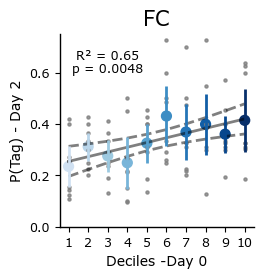

In [21]:
fig,ax=plt.subplots(figsize=(2.5,2.5))

#regression
plt.plot(np.arange(1,11),results.fittedvalues,'k',alpha=.5)
plt.plot(np.arange(1,11),ci_low,'k--',alpha=.5)
plt.plot(np.arange(1,11),ci_hi,'k--',alpha=.5)
#data
sb.regplot(data=deciles_fc,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
plt.errorbar(np.arange(1,11),means,yerr=errs,linewidth=2,ecolor=tencolors,linestyle='')
sb.regplot(data=deciles_fc,x='Deciles',y='P(Tagged)',fit_reg=False,color='grey',scatter_kws={'s':5})
#labels axes
plt.ylabel('P(Tag) - Day 2')
plt.xlabel('Deciles -Day 0')
plt.xticks(np.arange(1,11))
#statistics
plt.text(3,.65,f"R\u00b2 = {np.round(rsq,2)}",ha='center',size=9)
plt.text(3,.6,f"p = {np.round(pval,4)}",ha='center',size=9)
plt.ylim([0,.75])
plt.title('FC')
sb.despine()
plt.savefig('deciles_baselinerate_ptag_fc.svg',transparent=True)

# HC ONLY

## Figure 2F Stats

In [22]:
### plot only fc mice
deciles_hc = pd.DataFrame()
hc_mice = ['217R','217N','218L','589L','992L','994R','034R','1912L']
for ani in hc_mice:
    ani_df = df.loc[(df['Animal']==ani)&(df['Session']=='Baseline')].reset_index(drop=True)
    df_ani,cells_df= calculate_deciles_ani(ani_df)
    df_ani['Deciles'] = np.arange(1,11)
    deciles_hc = pd.concat([deciles_hc,df_ani],ignore_index=True)

deciles_hc['Decile']=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']*len(hc_mice)

Y = [np.mean(deciles_hc['P(Tagged)'].loc[deciles_hc['Deciles']==d].values) for d in np.arange(1,11)]
X = np.arange(0,10)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()

pred_ols = results.get_prediction()
ci_low = pred_ols.summary_frame()["mean_ci_lower"]
ci_hi = pred_ols.summary_frame()["mean_ci_upper"]

pval = results.f_pvalue
rsq = results.rsquared
results.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     26.37
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000891
Time:                        15:05:57   Log-Likelihood:                 19.918
No. Observations:                  10   AIC:                            -35.84
Df Residuals:                       8   BIC:                            -35.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2267      0.022     10.447      0.000       0.177       0.277
x1             0.0209      0.004      5.135      0.001       0.011       0.030
==============================================================================
Omnibus:                        7.296   Durbin-Watson:                   1.628
Prob(Omnibus):                  0.026   Jarque-Bera (JB):                2.835
Skew:                           1.200   Prob(JB):                        0.242
Kurtosis:                       4.024   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<ErrorbarContainer object of 3 artists>

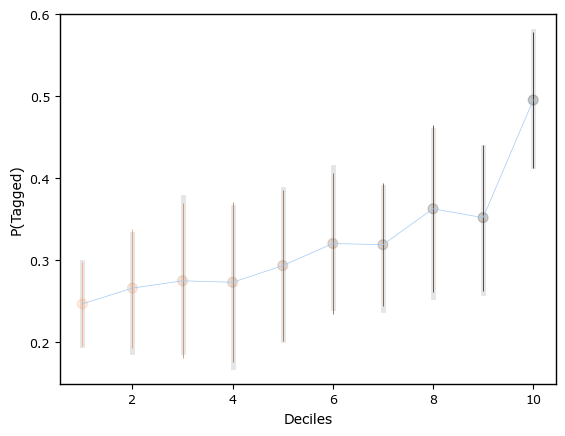

In [23]:
cmap=mpl.cm.get_cmap('copper_r')
colors = np.linspace(.2,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
deciles_hc['color'] = [cmap(colors[i]) for i in range(len(colors))]*len(hc_mice)
sb.regplot(data=deciles_hc,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=95,fit_reg=False,color='gray',scatter_kws={'alpha':.2,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
ax1 = plt.gca()
lower = [line.get_ydata().min() for line in ax1.lines]
upper = [line.get_ydata().max() for line in ax1.lines]
means = ax1.collections[0].get_offsets()[:, 1]
errs = (np.array(upper)-np.array(lower))/2
plt.errorbar(np.arange(1,11),means,yerr=errs,linewidth=.5,ecolor=tencolors)

## Figure 2F

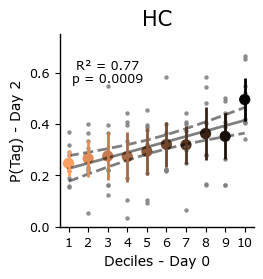

In [24]:
fig,ax=plt.subplots(figsize=(2.5,2.5))

#regression
plt.plot(np.arange(1,11),results.fittedvalues,'k',alpha=.5)
plt.plot(np.arange(1,11),ci_low,'k--',alpha=.5)
plt.plot(np.arange(1,11),ci_hi,'k--',alpha=.5)
#data
sb.regplot(data=deciles_hc,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
plt.errorbar(np.arange(1,11),means,yerr=errs,linewidth=2,ecolor=tencolors,linestyle='')
sb.regplot(data=deciles_hc,x='Deciles',y='P(Tagged)',fit_reg=False,color='grey',scatter_kws={'s':5})
#labels axes
plt.ylabel('P(Tag) - Day 2')
plt.xlabel('Deciles - Day 0')
plt.xticks(np.arange(1,11))
#statistic
plt.text(3,.61,f"R\u00b2 = {np.round(rsq,2)}",ha='center',size=9)
plt.text(3,.56,f"p = {np.round(pval,4)}",ha='center',size=9)
sb.despine()
plt.ylim([0,.75])
plt.title('HC')
plt.savefig('deciles_baselinerate_ptag_hc.svg',transparent=True)